In [128]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
import warnings
import xarray as xr
import matplotlib.pyplot as plt
import xbudget
import xwmt
import xwmb
from regionate import MaskRegions, GriddedRegion
from CM4Xutils import *

In [96]:
local_path_to_budgets_zarr = "../../../codedev/CM4Xutils/data/coarsened/CM4Xp125_budgets_sigma2_1850-1854.zarr"

In [97]:
ds = xr.open_zarr(local_path_to_budgets_zarr)

In [98]:
grid = ds_to_grid(ds.fillna(0.))
grid._ds = grid._ds.assign_coords({
    "sigma2_l_target": grid._ds['sigma2_l'].rename({"sigma2_l":"sigma2_l_target"}),
    "sigma2_i_target": grid._ds['sigma2_i'].rename({"sigma2_i":"sigma2_i_target"}),
})
grid = xwmt.add_gridcoords(
    grid,
    {"Z_target": {"center": "sigma2_l_target", "outer": "sigma2_i_target"}},
    {"Z_target": "extend"}
)

Inferring Z grid coordinate: density `sigma2`


In [99]:
wm = xwmt.WaterMass(grid)
for v in ["hflso", "hfsso", "rlntds"]:
    attrs = grid._ds[v].attrs.copy()
    grid._ds[v] = wm.expand_surface_array_vertically(grid._ds[v], target_position="center")
    grid._ds[v].attrs = attrs

/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.con

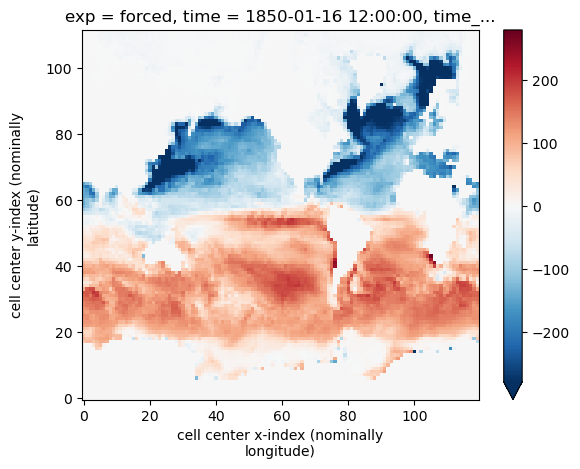

In [116]:
(grid._ds["hflso"] + grid._ds["hfsso"] + grid._ds["rlntds"] + grid._ds["rsdoabsorb"]).sum("sigma2_l").isel(exp=0, time=0).plot(robust=True)

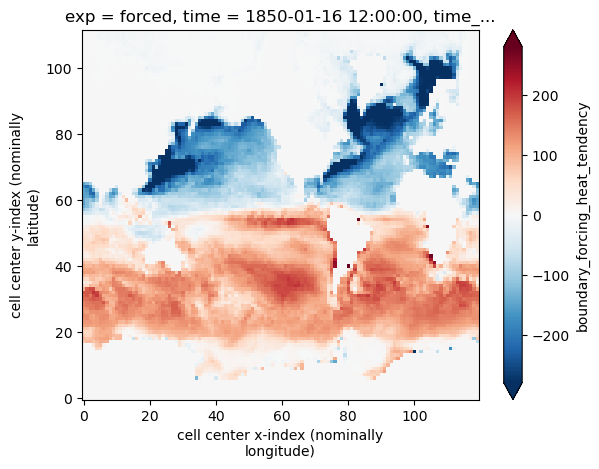

In [117]:
(grid._ds["boundary_forcing_heat_tendency"]).sum("sigma2_l").isel(exp=0, time=0).plot(robust=True)

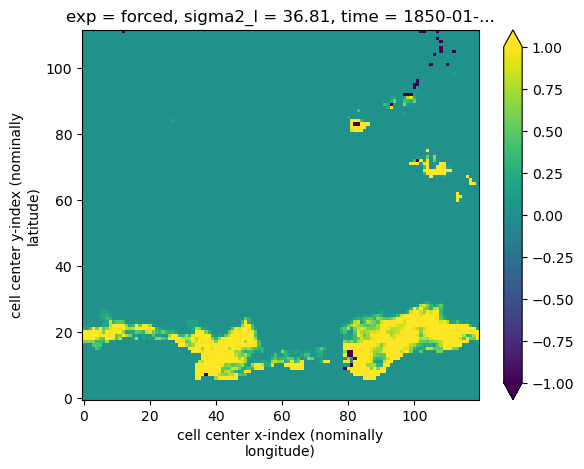

In [124]:
(grid._ds["hflso"] + grid._ds["hfsso"] + grid._ds["rlntds"] + grid._ds["rsdoabsorb"]).isel(exp=0, time=0).sel(sigma2_l=36.8, method="nearest").plot(vmin=-1, vmax=1)

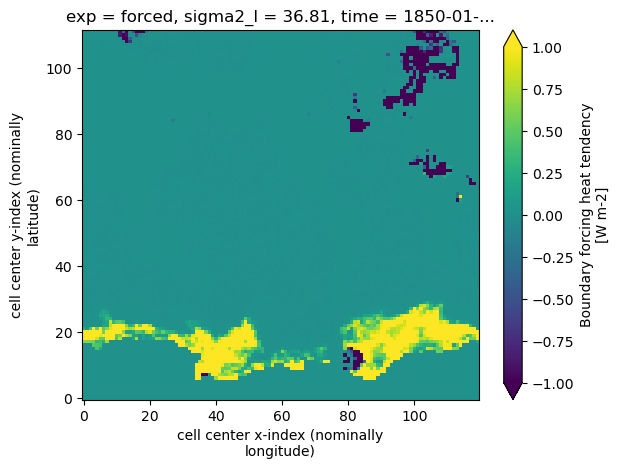

In [123]:
grid._ds["boundary_forcing_heat_tendency"].isel(exp=0, time=0).sel(sigma2_l=36.8, method="nearest").plot(vmin=-1, vmax=1)

In [127]:
grid._ds["salt_rhs_sum_surface_exchange_flux_sum_advective_sum"]

<xarray.DataArray 'salt_rhs_sum_surface_exchange_flux_sum_advective_sum' (
                                                                          exp: 2,
                                                                          time: 60,
                                                                          yh: 112,
                                                                          xh: 120)> Size: 13MB
dask.array<add, shape=(2, 60, 112, 120), dtype=float64, chunksize=(2, 60, 112, 120), chunktype=numpy.ndarray>
Coordinates:
    areacello        (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
    deptho           (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
  * exp              (exp) object 16B 'forced' 'control'
    geolat           (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
    geolon           (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
    lat              (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
    lon              (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
  * time             (time) object 480B 1850-01-16 12:00:00 ... 1854-12-16 12...
    time_since_init  (time) object 480B dask.array<chunksize=(60,), meta=np.ndarray>
    wet              (yh, xh) float64 108kB dask.array<chunksize=(112, 120), meta=np.ndarray>
  * xh               (xh) int64 960B 0 1 2 3 4 5 6 ... 114 115 116 117 118 119
  * yh               (yh) int64 896B 0 1 2 3 4 5 6 ... 106 107 108 109 110 111
Attributes:
    provenance:  ['salt_rhs_sum_surface_exchange_flux_sum_advective_sum_rain_...

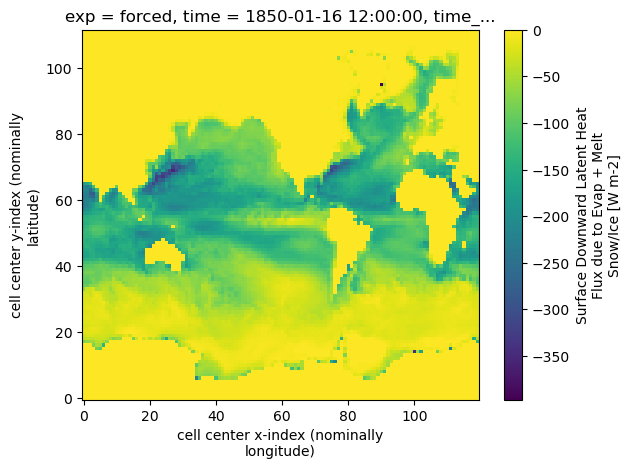

In [101]:
ds["hflso"].isel(exp=0, time=0).fillna(0.).plot()

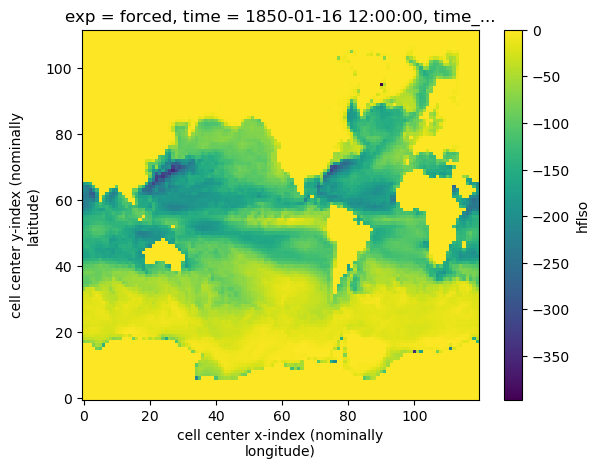

In [102]:
grid._ds["hflso"].sum("sigma2_l").isel(exp=0, time=0).plot()

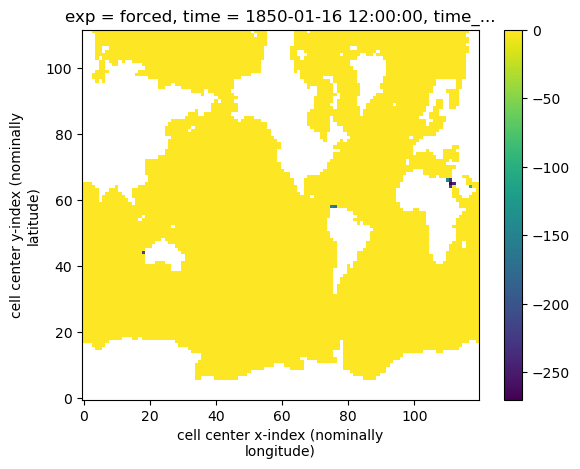

In [103]:
(ds["hflso"].isel(exp=0, time=0) - grid._ds["hflso"].sum("sigma2_l").isel(exp=0, time=0).data).plot()

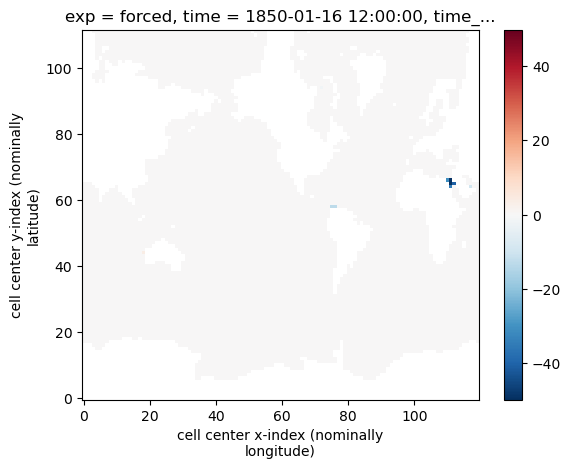

In [104]:
(ds["hfsso"].isel(exp=0, time=0) - grid._ds["hfsso"].sum("sigma2_l").isel(exp=0, time=0).data).plot()

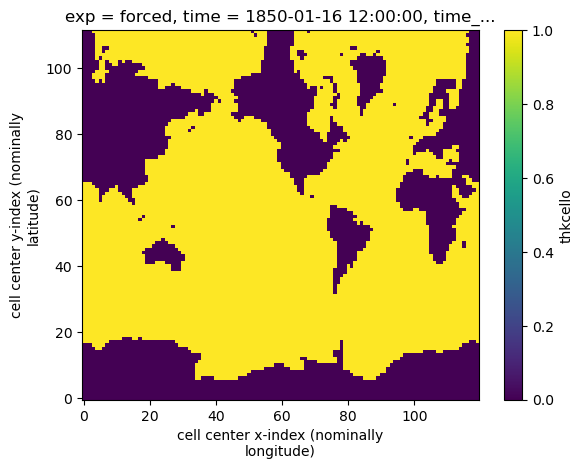

In [105]:
(ds["thkcello"].isel(exp=0, time=0).sum("sigma2_l") > 0).plot()

flux_true = grid._ds["rlntds"].isel(exp=0, time=0).compute()
flux_conv = wmb.expand_surface_array_vertically(grid._ds["rlntds"], target_position="center").isel(exp=0, time=0).compute()

flux_true.plot(vmin=-120, vmax=0)

flux_conv.isel(sigma2_l=30).plot(vmin=-120, vmax=0)

flux_conv.sum("sigma2_l").plot(vmin=-120, vmax=0)

In [106]:
grid._ds["mask"] = (
    (grid._ds['geolat'] <= -40)
)

In [107]:
regions = MaskRegions(grid._ds.mask, grid).region_dict
antarctic = regions[0] #there are more in this list if there are multiple contours 
region = GriddedRegion("antarctic", antarctic.lons, antarctic.lats, grid, ij=(antarctic.i, antarctic.j))

In [108]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    budgets_dict = xbudget.load_yaml("MOM6_AABW.yaml")
    xbudget.collect_budgets(grid, budgets_dict)

    wmb = xwmb.WaterMassBudget(
        grid,
        budgets_dict, 
        #region
    ) #if region not passed, the whole globe is taken
    wmb.mass_budget("sigma2", greater_than=True, default_bins=False, 
                    integrate=True, along_section=False)

    budgets_dict = xbudget.load_yaml("MOM6_AABW.yaml")
    xbudget.collect_budgets(grid, budgets_dict)
    
    wmb_decomp = xwmb.WaterMassBudget(
        grid,
        budgets_dict, 
        #region, 
        decompose=["surface_exchange_flux", "nonadvective", "advective"]
    ) #if region not passed, the whole globe is taken
    wmb_decomp.mass_budget("sigma2", greater_than=True, default_bins=False, 
                    integrate=True, along_section=False)

New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_basal
New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_icebergs
New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_sea_ice


/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.con

New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_virtual_precip_restoring
New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_rain_and_ice
New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_rivers


/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.con

New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_snow
New treatment of surface fluxes for salt_rhs_sum_surface_exchange_flux_sum_advective_sum_evaporation


/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


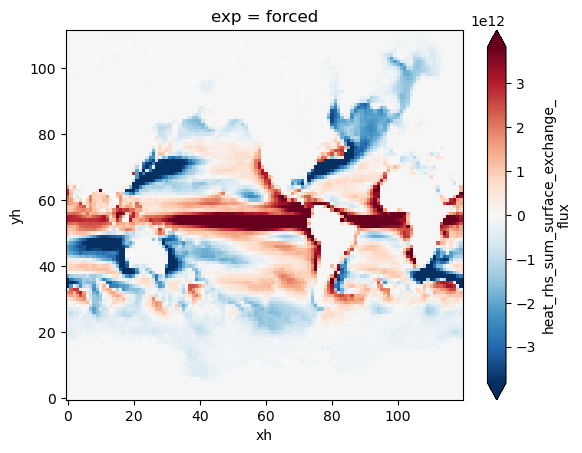

In [94]:
wmb_decomp.grid._ds["heat_rhs_sum_surface_exchange_flux"].isel(exp=0).mean("time").sum("sigma2_l").plot(robust=True)

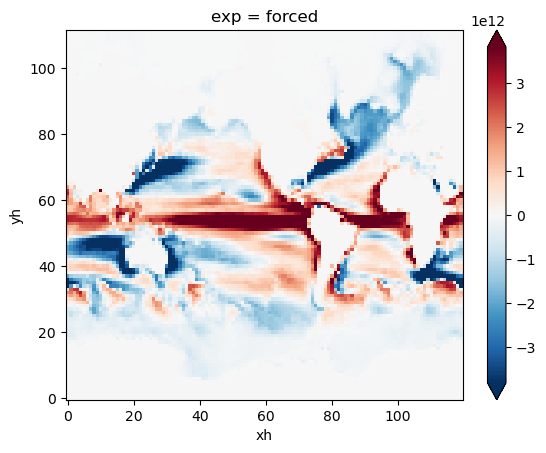

In [26]:
def sum_sigma2(da):
    d = "sigma2_l"
    return da.sum(d) if d in da.dims else da

term_list = [
    "heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_shortwave", 
    "heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_longwave",
    "heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_sensible",
    "heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_latent", 
    "heat_rhs_sum_surface_exchange_flux_sum_advective"
]
sum([sum_sigma2(wmb_decomp.grid._ds[v].isel(exp=0).mean("time")) for v in term_list]).plot(robust=True)

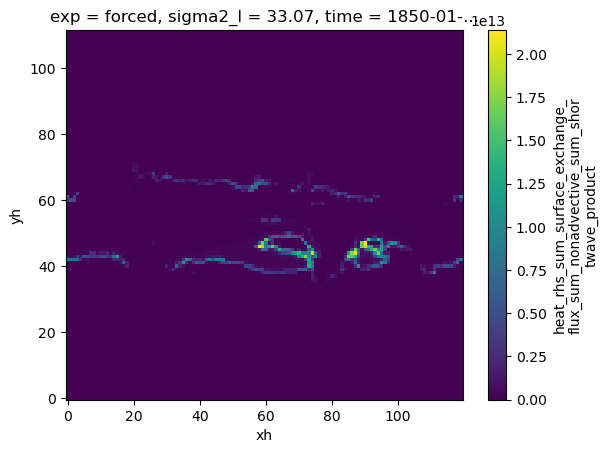

In [27]:
wmb_decomp.grid._ds.heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_shortwave_product.isel(exp=0, time=0).isel(sigma2_l=20).plot()

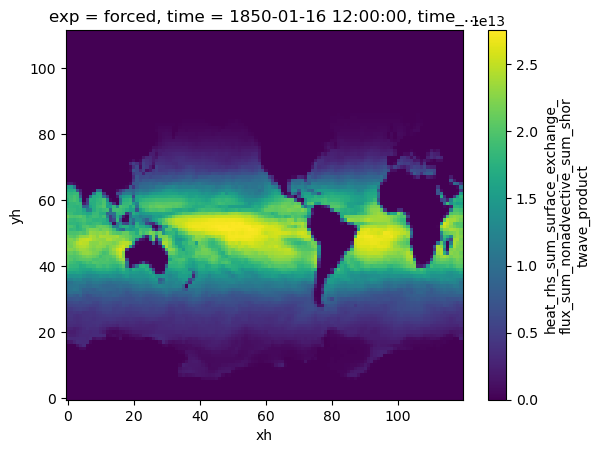

In [15]:
wmb_decomp.grid._ds.heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_shortwave_product.isel(exp=0, time=0).sum("sigma2_l").plot()

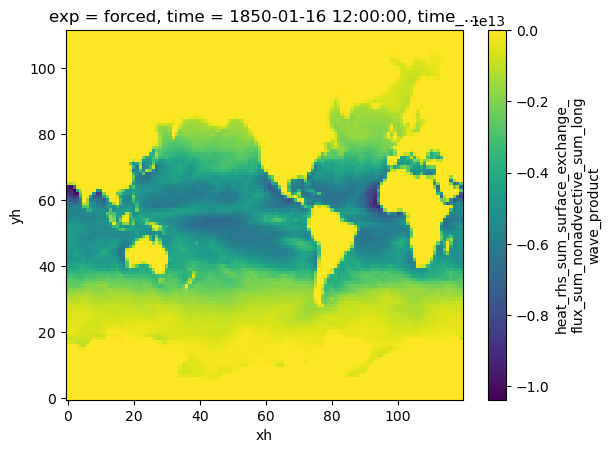

In [16]:
wmb_decomp.grid._ds.heat_rhs_sum_surface_exchange_flux_sum_nonadvective_sum_longwave_product.isel(exp=0, time=0).plot()

In [33]:
wmb.integrate_transformations(la

In [109]:
decomp_heat_vars = ["surface_exchange_flux_nonadvective_longwave_heat", 
                    "surface_exchange_flux_nonadvective_shortwave_heat",
                    "surface_exchange_flux_nonadvective_sensible_heat",
                    "surface_exchange_flux_nonadvective_latent_heat", 
                    "surface_exchange_flux_advective_mass_transfer_heat",
                    "surface_exchange_flux_heat"]

decomp_vars_ds = wmb_decomp.wmt[decomp_heat_vars[:-1]].mean("time").compute() #calculate surface_exchange_flux_heat
lhs = wmb.wmt[decomp_heat_vars[-1]].mean("time").compute() #linear sum terms
rhs = 0 * lhs
for vname in decomp_heat_vars[:-1]:
    rhs += decomp_vars_ds[vname]

Text(0.5, 1.0, 'Surface Exchange Heat Fluxes Comparison')

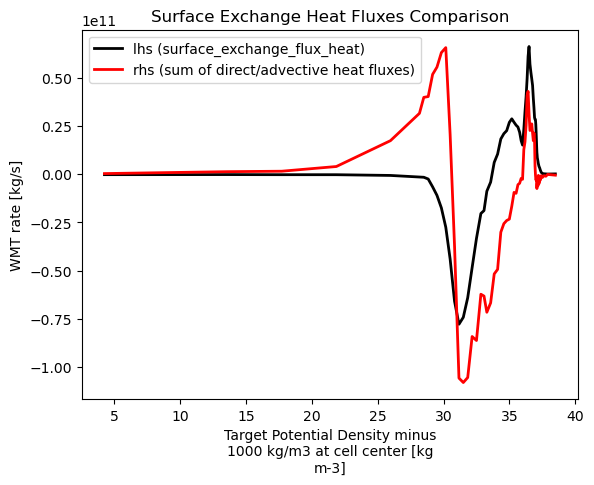

In [112]:
fig, ax = plt.subplots()
lhs.isel(exp = 0).plot(label = "lhs (surface_exchange_flux_heat)", ax = ax, c = "black", linewidth = 2)
rhs.isel(exp = 0).plot(label = "rhs (sum of direct/advective heat fluxes)", ax = ax, linewidth = 2, c  = "red")
ax.legend()
ax.set_ylabel("WMT rate [kg/s]")
ax.set_title("Surface Exchange Heat Fluxes Comparison")

Text(0.5, 1.0, 'Surface Exchange Heat Fluxes Comparison')

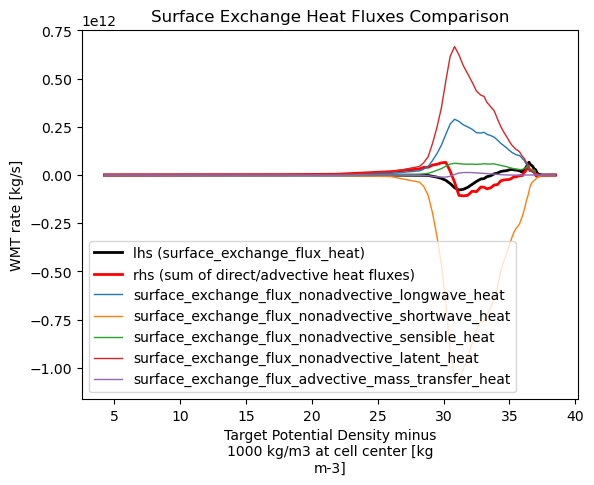

In [111]:
fig, ax = plt.subplots()
lhs.isel(exp = 0).plot(label = "lhs (surface_exchange_flux_heat)", ax = ax, c = "black", linewidth = 2)
rhs.isel(exp = 0).plot(label = "rhs (sum of direct/advective heat fluxes)", ax = ax, linewidth = 2, c  = "red")
for vname in decomp_heat_vars[:-1]:
    decomp_vars_ds[vname].isel(exp = 0).plot(label = vname, ax = ax, linewidth = 1)
ax.legend()
ax.set_ylabel("WMT rate [kg/s]")
ax.set_title("Surface Exchange Heat Fluxes Comparison")

In [91]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    budgets_dict = xbudget.load_preset_budget(model="MOM6_3Donly")
    xbudget.collect_budgets(grid, budgets_dict)
    
    wmb = xwmb.WaterMassBudget(
        grid,
        budgets_dict,
        method="xgcm"
    )
    wmb.mass_budget("sigma2", greater_than=True, default_bins=False, integrate=True, along_section=False)
    wmt = wmb.wmt

In [92]:
%%time
wmt_mean = (wmt.sel(exp="control").mean("time")/1035*1e-6)
wmt_mean.load()

CPU times: user 2min 15s, sys: 1min 43s, total: 3min 59s
Wall time: 36.9 s


<xarray.Dataset> Size: 579kB
Dimensions:                                         (sigma2_l_target: 74,
                                                     sigma2_i_target: 75,
                                                     time_bounds: 61, yh: 90,
                                                     xh: 120)
Coordinates: (12/13)
    exp                                             <U7 28B 'control'
  * sigma2_l_target                                 (sigma2_l_target) float64 592B ...
  * sigma2_i_target                                 (sigma2_i_target) float64 600B ...
  * time_bounds                                     (time_bounds) object 488B ...
    areacello                                       (yh, xh) float64 86kB 5.0...
    deptho                                          (yh, xh) float32 43kB 0.0...
    ...                                              ...
    geolon                                          (yh, xh) float64 86kB -29...
    lat                                             (yh, xh) float64 86kB -79...
    lon                                             (yh, xh) float64 86kB -29...
    wet                                             (yh, xh) float32 43kB 0.0...
  * xh                                              (xh) int64 960B 0 1 ... 119
  * yh                                              (yh) int64 720B 0 1 ... 89
Data variables: (12/39)
    Eulerian_tendency_heat                          (sigma2_l_target) float64 592B ...
    Eulerian_tendency_salt                          (sigma2_l_target) float64 592B ...
    diffusion_heat                                  (sigma2_l_target) float64 592B ...
    diffusion_salt                                  (sigma2_l_target) float64 592B ...
    surface_ocean_flux_advective_negative_rhs_heat  (sigma2_l_target) float64 592B ...
    surface_ocean_flux_advective_negative_rhs_salt  (sigma2_l_target) float64 592B ...
    ...                                              ...
    mass_tendency                                   (sigma2_l_target) float64 592B ...
    dt                                              float64 8B 0.002539
    realized_transformation                         (sigma2_l_target) float64 592B ...
    spurious_numerical_mixing                       (sigma2_l_target) float64 592B ...
    advection_plus_BC                               (sigma2_l_target) float64 592B ...
    diabatic_advection                              (sigma2_l_target) float64 592B ...

In [93]:
def stairs(wmt, var, units="kg", **kwargs):
    da = wmt[var]
    coord = wmt[[c for c in wmt.coords if "l_target" in c][0]]
    coord_bounds = wmt[[c for c in wmt.coords if "i_target" in c][0]]
    l = plt.stairs(da, coord_bounds, **kwargs, orientation="horizontal")
    plt.xlabel(f"mean transformation rate [{units}]")
    return l

(-50.0, 50.0)

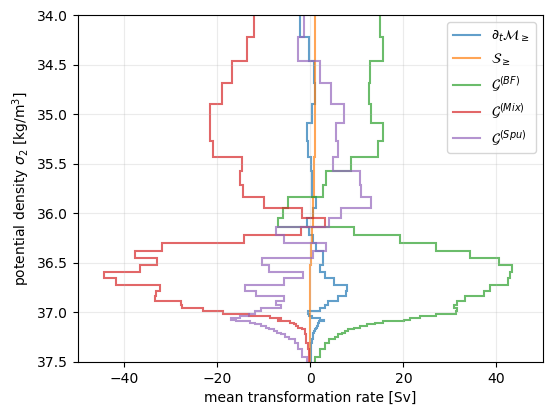

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4.5))

kwargs = {"units":"Sv", "alpha":0.7, "lw":1.5}

stairs(-wmt_mean, 'mass_tendency',             label=r"$\partial_{t} \mathcal{M}_{\geq}$",**kwargs)
stairs( wmt_mean, 'mass_source',               label=r"$\mathcal{S}_{\geq}$",            **kwargs)
stairs( wmt_mean, 'boundary_fluxes',           label=r"$\mathcal{G}^{(BF)}$",      **kwargs)
stairs( wmt_mean, 'diffusion',                 label=r"$\mathcal{G}^{(Mix)}$",     **kwargs)
stairs( wmt_mean, 'spurious_numerical_mixing', label=r"$\mathcal{G}^{(Spu)}$", **kwargs)

plt.legend(loc="upper right")
plt.grid(True, alpha=0.25)
plt.ylabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$]");
plt.ylim(37.5, 34.);
plt.xlim(-50, 50)